In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy

from scipy.optimize import curve_fit

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:

odir = "../../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [6]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [7]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [8]:
def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

In [9]:
def cf_nl_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    cf[mask] = -1
    return cf

In [10]:
def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return xi_d

In [11]:
def pk_from_cf(logks):
    rmax = 100
    dr=0.01
    r_list = np.arange(1e-4,rmax,dr)
    cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [12]:
def pk_from_cf_nl(logks):
    rmax = 1000
    dr=0.1
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_nl_excl(r_list, bias=2, R=0.37)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [13]:
logks = np.arange(-1.5,1.5,0.1)
Pk = pk_from_cf(logks)
Pk_1R = pk_from_cf_nl(logks)

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

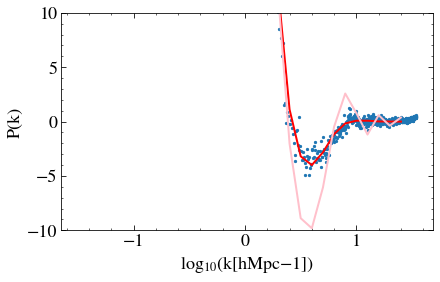

In [154]:

plt.scatter(np.log10(Pk_sum10["k"]),Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"], s=5, label="Tot")
plt.plot(logks, Pk,c="red")
plt.plot(logks, Pk_1R,c="pink")
plt.ylim(-10,10)
plt.ylabel('P(k)')
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


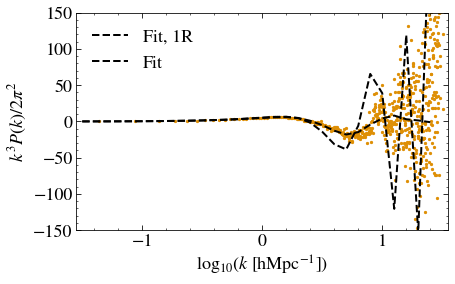

In [155]:
kcoef_tng = Pk_sum10["k"]**3/(2*np.pi**2)
kcoef_fit = (10**np.array(logks))**3/(2*np.pi**2)
plt.scatter(np.log10(Pk_sum10["k"]),kcoef_tng*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), s=5, label="TNG", c=palette_tab10[1])

plt.plot(logks, kcoef_fit*Pk,c="k", linestyle="dashed", label="Fit")
plt.plot(logks, kcoef_fit*Pk_1R,c="k", linestyle="dashed", label="Fit, 1R")

plt.ylabel(r"$k^3 P(k)/2\pi^2$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

plt.ylim(-150,150)
plt.xlim(-1.55,1.55)
handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], markerscale=3)
#plt.savefig("../../figures/tng_exclusion_fit.pdf", format="pdf", bbox_inches="tight")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in log10
  """
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in log10
  import sys


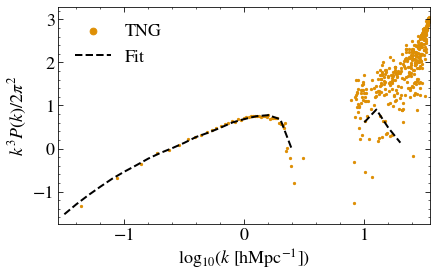

In [15]:
ks_tng = Pk_sum10["k"]
logks_tng = np.log10(ks_tng)
kcoef_tng = Pk_sum10["k"]**3/(2*np.pi**2)
kcoef_fit = (10**np.array(logks))**3/(2*np.pi**2)
plt.scatter(np.log10(Pk_sum10["k"]),np.log10(kcoef_tng*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), s=5, label="TNG", c=palette_tab10[1])

plt.plot(logks, np.log10(kcoef_fit*Pk),c="k", linestyle="dashed", label="Fit")
plt.ylabel(r"$k^3 P(k)/2\pi^2$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

#plt.ylim(-150,150)
plt.xlim(-1.55,1.55)
handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], markerscale=3)
#plt.savefig("../../figures/tng_exclusion_fit.pdf", format="pdf", bbox_inches="tight")


Text(0, 0.5, '$ P(k)\\ [\\mathrm{h^3 Mpc^{-3}}]$')

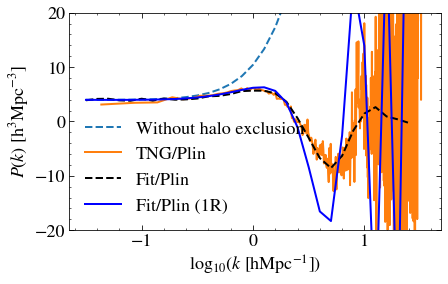

In [163]:
plt.plot(logks, 4*Pnl(10**logks)/Plin(10**logks), linestyle="dashed", label="Without halo exclusion")
plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng), label="TNG/Plin")
plt.plot(logks, Pk/Plin(10**logks),c="k", linestyle="dashed", label="Fit/Plin")
plt.plot(logks, Pk_1R/Plin(10**logks),c="blue", linestyle="solid", label="Fit/Plin (1R)")

plt.ylim(-20,20)

plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel(r"$ P(k)\ [\mathrm{h^3 Mpc^{-3}}]$")

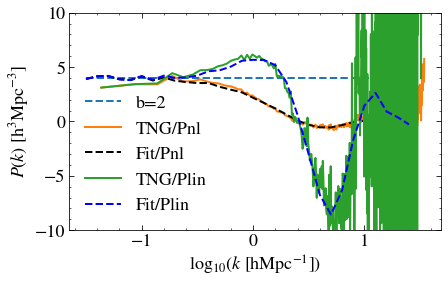

In [175]:
plt.plot(logks, [4]*len(logks), linestyle="dashed", label="b=2")
#plt.plot(logks, 2*Pnl(10**logks)/Plin(10**logks))
plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Pnl(ks_tng), label="TNG/Pnl")
plt.plot(logks, Pk/Pnl(10**logks),c="k", linestyle="dashed", label="Fit/Pnl")

plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng), label="TNG/Plin")
plt.plot(logks, Pk/Plin(10**logks),c="blue", linestyle="dashed", label="Fit/Plin")

plt.ylim(-10,10)

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel(r"$ P(k)\ [\mathrm{h^3 Mpc^{-3}}]$")
plt.legend()

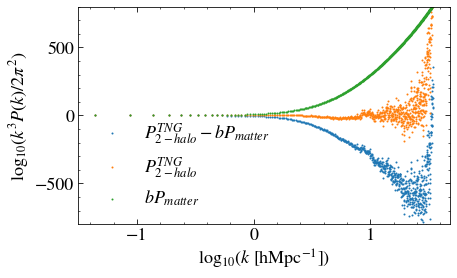

In [507]:
plt.scatter(logks_tng, kcoef_tng*((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-4*Pnl(ks_tng)), label="$P^{TNG}_{2-halo}-bP_{matter}$", s=1)
plt.scatter(logks_tng, kcoef_tng*((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P^{TNG}_{2-halo}$", s=1)

plt.scatter(logks_tng, kcoef_tng*(4*Pnl(ks_tng)), s=1, label="$bP_{matter}$")

plt.ylim(-800,800)
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.legend()

In [515]:
stoch_term = Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])

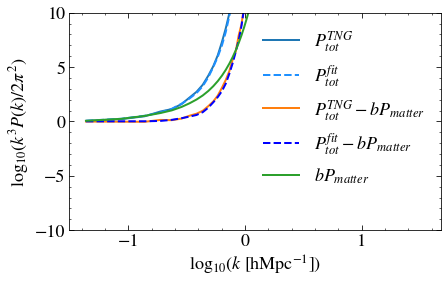

In [533]:
plt.plot(logks_tng, kcoef_tng*((Pk_gal10["power"].real)), label="$P^{TNG}_{tot}$")
plt.plot(logks_tng, kcoef_tng*((pk_from_cf(logks_tng)+stoch_term)),c="DodgerBlue", linestyle="dashed", label="$P^{fit}_{tot}$")




plt.plot(logks_tng, kcoef_tng*((Pk_gal10["power"].real)-4*Pnl(ks_tng)), label="$P^{TNG}_{tot}-bP_{matter}$")
plt.plot(logks_tng, kcoef_tng*((pk_from_cf(logks_tng)+stoch_term)-4*Pnl(ks_tng)),c="blue", linestyle="dashed", label="$P^{fit}_{tot}-bP_{matter}$")


#plt.plot(logks_tng, kcoef_tng*((Pk_sum10["power"].real)), label="$P^{TNG}_{2-halo}$")

plt.plot(logks_tng, kcoef_tng*(4*Pnl(ks_tng)), label="$bP_{matter}$")


plt.ylim(-10,10)
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


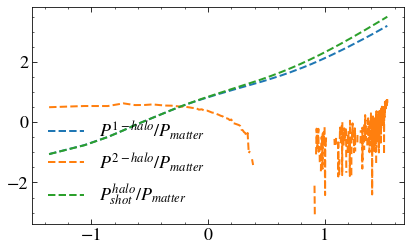

In [26]:
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-halo2)/(Pnl(ks_tng))),linestyle="dashed", label="$P^{1-halo}/P_{matter}$")
plt.plot(logks_tng, np.log10((halo2)/(Pnl(ks_tng))),linestyle="dashed", label="$P^{2-halo}/P_{matter}$")
plt.plot(logks_tng, np.log10((Pk_sum10.attrs["shotnoise"])/(Pnl(ks_tng))),linestyle="dashed", label="$P^{halo}_{shot}/P_{matter}$")

plt.legend()

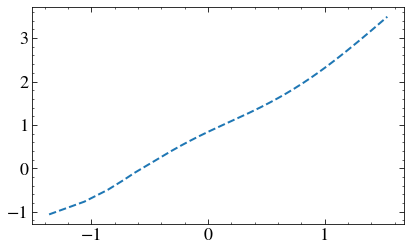

In [25]:
plt.plot(logks_tng, np.log10((Pk_sum10.attrs["shotnoise"])/(Pnl(ks_tng))),linestyle="dashed", label="$P^{1-halo}/P_{matter}$")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


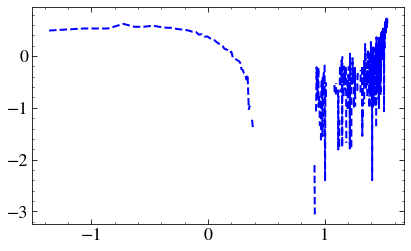

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


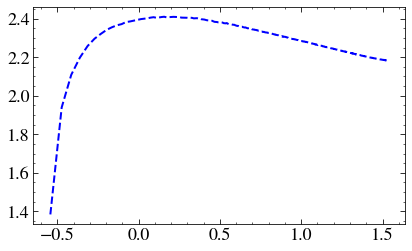

In [538]:
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-halo2)-Pnl(ks_tng)),c="blue", linestyle="dashed", label="$P^{fit}_{tot}-bP_{matter}$")


In [ ]:
plt.scatter(logks_tng, kcoef_tng*((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-4*Pnl(ks_tng)), label="$P^{TNG}_{2-halo}-bP_{matter}$", s=1)
plt.scatter(logks_tng, kcoef_tng*((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P^{TNG}_{2-halo}$", s=1)

plt.scatter(logks_tng, kcoef_tng*(4*Pnl(ks_tng)), s=1, label="$bP_{matter}$")

plt.ylim(-800,800)
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.legend()

(-80.0, 10.0)

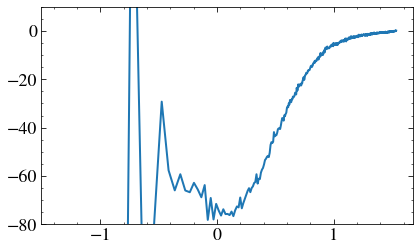

In [486]:
plt.plot(logks_tng, ((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-(4*Pnl(ks_tng))), label="TNG(2-halo)-Pnl")
plt.ylim(-80,10)

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

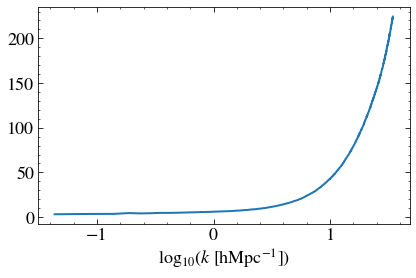

In [84]:

#plt.plot(logks_tng, (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"])/Plin(ks_tng))

plt.plot(logks_tng, (Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"])/Pnl(ks_tng))
    
#plt.plot(logks_tng, (Pk_gal10["power"].real-Pk_sum10.attrs["shotnoise"])/Pnl(ks_tng))
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


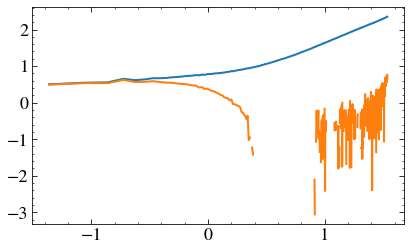

In [95]:
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"])/Pnl(ks_tng)))
plt.plot(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Pnl(ks_tng)), label="TNG/Pnl")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

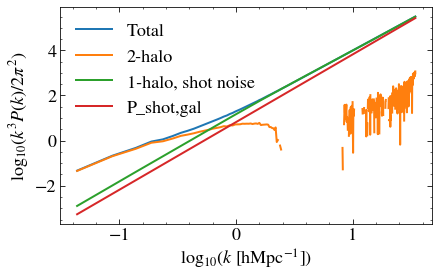

In [130]:
plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_gal10["power"].real)), label="Total")

plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="2-halo")

plt.plot(logks_tng,np.log10(kcoef_tng*(Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))), label="1-halo, shot noise")

#plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_sum10.attrs["shotnoise"])), label="P_shot,halo")
plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_gal10.attrs["shotnoise"])), label="P_shot,gal")


plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

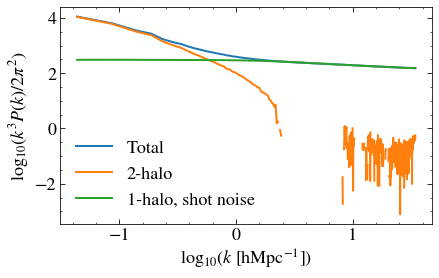

In [127]:
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real)), label="Total")

plt.plot(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="2-halo")

plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))), label="1-halo, shot noise")

#plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_sum10.attrs["shotnoise"])), label="2-halo")
#plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_gal10.attrs["shotnoise"])), label="2-halo")

plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

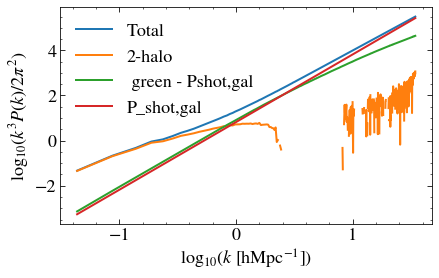

In [131]:
plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_gal10["power"].real)), label="Total")

plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="2-halo")

#plt.plot(logks_tng,np.log10(kcoef_tng*(Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))), label="1-halo, shot noise")

plt.plot(logks_tng,np.log10(kcoef_tng*(Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
plt.plot(logks_tng, np.log10(kcoef_tng*(Pk_gal10.attrs["shotnoise"])), label="P_shot,gal")


plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in log10
  
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


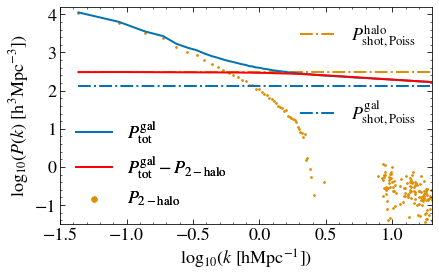

In [579]:
plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot,Poiss}}$", linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot,Poiss}}$", linestyle="dashdot", c=palette_tab10[1])

plt.plot(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$", c=palette_tab10[0])

plt.scatter(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2-halo}}$", s=3, c=palette_tab10[1])

plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))), label="$P^{\mathrm{gal}}_{\mathrm{tot}} - P_{\mathrm{2-halo}}$", c="red")


#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
#plt.plot(logks, np.log10(4*Pnl(10**logks)),c="k", linestyle="dashed", label="$P_{NL}$")
#plt.plot(logks, np.log10(4*Plin(10**logks)),c="k", linestyle="dotted", label="$P_{lin}$")

#plt.vlines(0.3, ymin=0,ymax=4)
#plt.ylim(0,4.2)
ax = plt.gca()
h, l = ax.get_legend_handles_labels()
leg = ax.legend(handles=h[:1], loc="upper right", bbox_to_anchor=(1,0.65))
ax.add_artist(leg)
leg = ax.legend(handles=h[1:2])
ax.add_artist(leg)
leg = ax.legend(handles=h[2:],markerscale=3)
ax.add_artist(leg)



plt.xlim(-1.5,1.3)
plt.ylim(-1.5, 4.2)

plt.ylabel(r"$\mathrm{log}_{10}( P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
#plt.savefig("../../figures/ps_components.pdf", format="pdf", bbox_inches="tight")

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

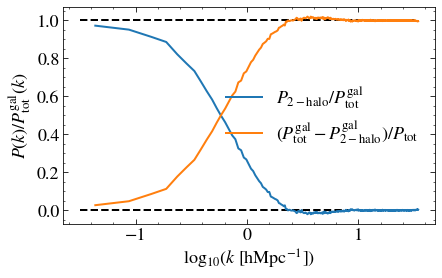

In [431]:
plt.plot([-1.5,1.5], [1,1], linestyle="dashed", c="k")
plt.plot([-1.5,1.5], [0,0], linestyle="dashed", c="k")
#plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{gal}}_{\mathrm{shot,Poiss}}$", linestyle="dashdot")
#plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{\mathrm{halo}}_{\mathrm{shot,Poiss}}$", linestyle="dashdot")

#plt.plot(logks_tng, np.log10((Pk_gal10["power"].real)), label="$P^{\mathrm{gal}}_{\mathrm{tot}}$")

plt.plot(logks_tng, ((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/(Pk_gal10["power"].real)), label="$P_{\mathrm{2-halo}}/P^{\mathrm{gal}}_{\mathrm{tot}}$")

plt.plot(logks_tng,((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))/(Pk_gal10["power"].real)), label="$(P^{\mathrm{gal}}_{\mathrm{tot}} - P^{\mathrm{gal}}_{\mathrm{2-halo}})/P_{\mathrm{tot}}$")


#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
#plt.plot(logks, np.log10(4*Pnl(10**logks)),c="k", linestyle="dashed", label="$P_{NL}$")
#plt.plot(logks, np.log10(4*Plin(10**logks)),c="k", linestyle="dotted", label="$P_{lin}$")


#plt.ylim(0,4.2)
plt.legend()

plt.ylabel(r"$P(k)/ P^{\mathrm{gal}}_{\mathrm{tot}}(k)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

In [413]:
ks = 10**logks
kcoef = ks**3/(2*np.pi**2)

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

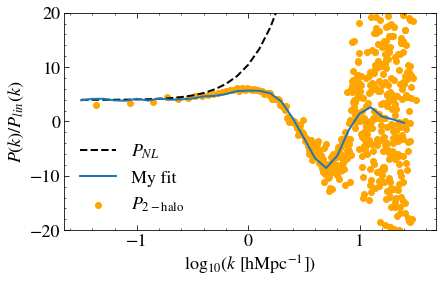

In [456]:
plt.plot(logks, 4*Pnl(10**logks)/Plin(10**logks),c="k", linestyle="dashed", label="$P_{NL}$")
plt.scatter(logks_tng, ((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(10**logks_tng)), label="$P_{\mathrm{2-halo}}$", c="orange")

plt.plot(logks, pk_from_cf(logks)/Plin(10**logks), label="My fit")
plt.ylim(-20,20)
plt.ylabel("$P(k)/P_{lin}(k)$")
plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

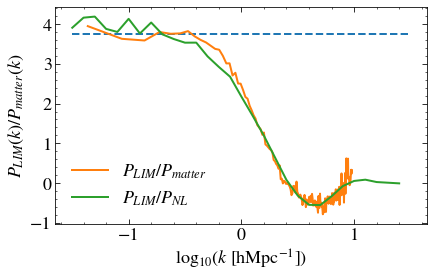

In [474]:
plt.plot([-1.5,1.5], [3.75, 3.75], linestyle="dashed")
plt.plot(np.log10(Pk2["k"][:191]), halo2[:191]/Pk2["power"].real[:191], label="$P_{LIM}/P_{matter}$")
#plt.plot(logks, pk_from_cf(logks)/Plin(10**logks), label="$P_{LIM}/P_{lin}$")
plt.plot(logks, pk_from_cf(logks)/Pnl(10**logks), label="$P_{LIM}/P_{NL}$")

#plt.ylim(-20,20)
plt.ylabel("$P_{LIM}(k)/P_{matter}(k)$")
plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

In [ ]:
#plt.plot(logks, 4*Pnl(10**logks)/Plin(10**logks),c="k", linestyle="dashed", label="$P_{NL}$")
plt.scatter(logks_tng, ((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(10**logks_tng)), label="$P_{\mathrm{2-halo}}$", c="orange")

plt.plot(logks, pk_from_cf(logks)/Plin(10**logks), label="My fit")
plt.ylim(-20,20)
plt.ylabel("$P(k)/P_{lin}(k)$")
plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

(-20.0, 100.0)

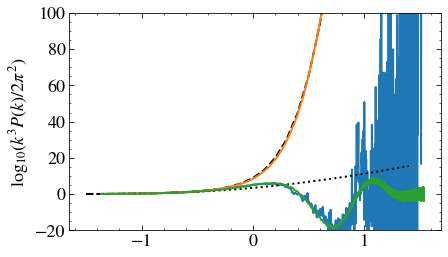

In [436]:
plt.plot(logks_tng, (kcoef_tng*(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="$P_{\mathrm{2-halo}}$")

plt.plot(logks, (kcoef*4*Pnl(10**logks)),c="k", linestyle="dashed", label="$P_{NL}$")
plt.plot(logks, (kcoef*4*Plin(10**logks)),c="k", linestyle="dotted", label="$P_{lin}$")
plt.plot(np.log10(Pk2["k"][:191]), (kcoef_tng[:191]*2**2*Pk2["power"].real[:191]), label="DM")
plt.plot(logks_tng,kcoef_tng*pk_from_cf(logks_tng))
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.ylim(-20,100)

In [ ]:
plt.plot(logks, np.log10(4*Pnl(10**logks)),c="k", linestyle="dashed", label="Halofit")
plt.plot(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="2-halo")


(100, 1000)

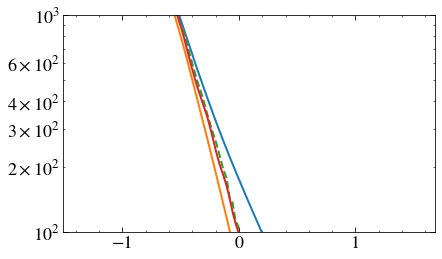

In [400]:
plt.plot(logks_tng, halofit)
plt.plot(logks_tng, linear)
plt.plot(logks_tng, halo2, linestyle="dashed")
plt.plot(logks_tng, pk_from_cf(logks_tng))
#plt.ylim(-1,100)
plt.yscale("log")
plt.ylim(100,1000)


In [338]:
odir = "../../ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk2 = pickle.load(f)

In [343]:
len(Pk2["power"])

191

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  


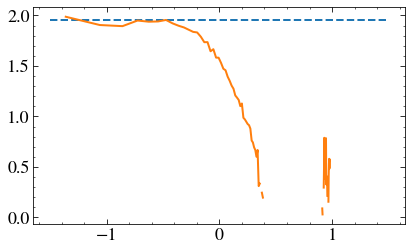

In [377]:
plt.plot([-1.5,1.5], [1.95, 1.95], linestyle="dashed")
plt.plot(np.log10(Pk2["k"][:191]), np.sqrt(halo2[:191]/Pk2["power"].real[:191]), label="DM")
#plt.plot(np.log10(Pk2["k"][:191]), np.sqrt(halo2[:191]/halofit[:191]*4), label="DM")


In [459]:
mask = logks_tng[:191] < -0.5
bias = np.sqrt(halo2[:191]/Pk2["power"].real[:191])[mask]
print(bias)
np.mean(bias**2)

[1.98672112 1.90476699 1.89365818 1.9491566  1.93771333 1.94023717]


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  


3.7466006717836513

NameError: name 'Pk2' is not defined

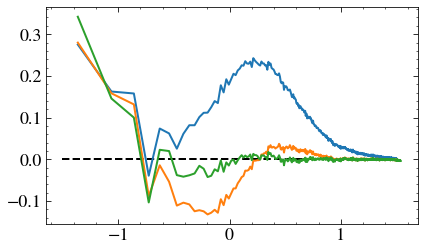

In [18]:
halo2 = Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]
halofit = 4*Pnl(10**logks_tng)
linear = 4*Plin(10**logks_tng)
total = Pk_gal10["power"].real
mask = logks_tng < 1.5

plt.plot([-1.5,1.5], [0,0],linestyle="dashed", c="k")

plt.plot(logks_tng[mask], ((halofit-halo2)/total)[mask], label="PNL")
plt.plot(logks_tng[mask], ((linear-halo2)/total)[mask], label="Plin")
plt.plot(logks_tng, ((pk_from_cf(logks_tng)-halo2)/total), label="My fit")
plt.plot(np.log10(Pk2["k"][:191]), (2**2*Pk2["power"].real[:191]-halo2[:191])/total[:191], label="DM")
plt.ylim(-0.05,0.4)
#plt.ylim(-0.1,0.1)
plt.ylabel("($P^{2-halo}_{fit}-P^{2-halo}_{TNG})/P_{total}$")
plt.legend()
#plt.yscale("log")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log10
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in log10
  app.launch_new_instance()


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

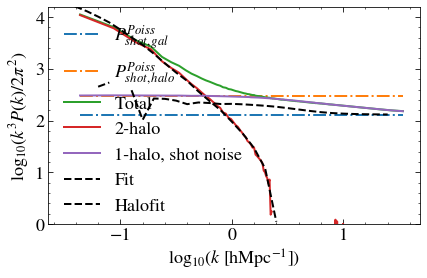

In [270]:
plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{Poiss}_{shot,gal}$", linestyle="dashdot")
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), label="$P^{Poiss}_{shot,halo}$", linestyle="dashdot")

plt.plot(logks_tng, np.log10((Pk_gal10["power"].real)), label="Total")

plt.plot(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])), label="2-halo")

plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))), label="1-halo, shot noise")
#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]))-Pk_gal10.attrs["shotnoise"]), label="1-halo, shot noise")


#plt.plot(logks_tng,np.log10((Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])), label=" green - Pshot,gal")
#plt.plot(logks, np.log10(4*Pnl(10**logks)),c="k", linestyle="dashed", label="Halofit")
#plt.plot(logks, np.log10(4*Plin(10**logks)),c="k", linestyle="dotted", label="Plin")
plt.plot(logks, np.log10(Pk),c="k", linestyle="dashed", label="Fit")
plt.plot(logks, np.log10((4*Pnl(10**logks)-Pk)+Pk_gal10.attrs["shotnoise"]),c="k", linestyle="dashed", label="Halofit")


plt.ylim(0,4.2)
plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

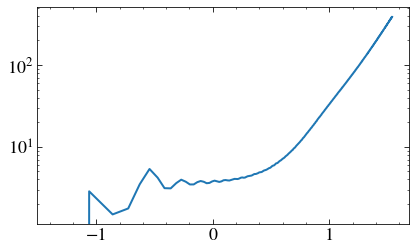

In [266]:

Pk_fit_2halo = pk_from_cf(logks_tng)
nl_1halo = 4*Pnl(10**logks_tng)-Pk_fit_2halo # nonlinear power spectrum minus 2-halo fit
# Actually maybe we shouldn't subtract fit?

tng_2halo = (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])
tng_remaining = Pk_gal10["power"].real - tng_2halo #- Pk_gal10.attrs["shotnoise"]

plt.plot(logks_tng,tng_remaining/nl_1halo, label="bias")

plt.yscale("log")

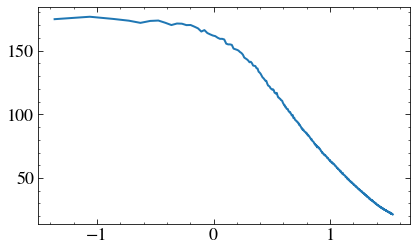

In [99]:
plt.plot(logks_tng,Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])-Pk_gal10.attrs["shotnoise"])


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in log10
  after removing the cwd from sys.path.


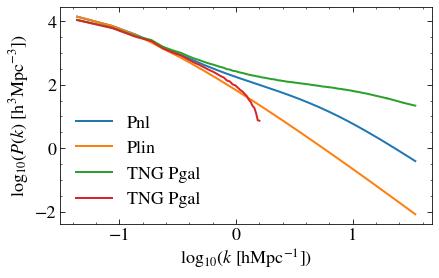

In [83]:
plt.plot(logks_tng, np.log10(4*Pnl(ks_tng)), label="Pnl")
plt.plot(logks_tng, np.log10(4*Plin(ks_tng)), label="Plin")
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-Pk_gal10.attrs["shotnoise"])), label="TNG Pgal")
plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-Pk_sum10.attrs["shotnoise"])), label="TNG Pgal")

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel(r"$\log_{10}(P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.legend()

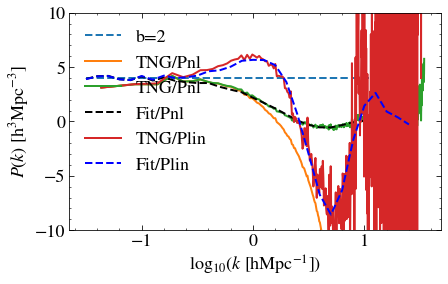

In [181]:
plt.plot(logks, [4]*len(logks), linestyle="dashed", label="b=2")
#plt.plot(logks, 2*Pnl(10**logks)/Plin(10**logks))

plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Pnl(ks_tng), label="TNG/Pnl")
plt.plot(logks, Pk/Pnl(10**logks),c="k", linestyle="dashed", label="Fit/Pnl")

plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng), label="TNG/Plin")
plt.plot(logks, Pk/Plin(10**logks),c="blue", linestyle="dashed", label="Fit/Plin")

plt.ylim(-10,10)

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel(r"$ P(k)\ [\mathrm{h^3 Mpc^{-3}}]$")
plt.legend()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


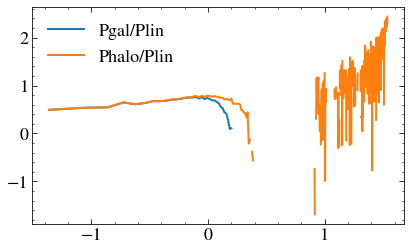

In [187]:

plt.plot(logks_tng, np.log10((Pk_gal10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng)), label="Pgal/Plin")
plt.plot(logks_tng, np.log10((Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng)), label="Phalo/Plin")
plt.legend()

In [197]:
one_halo_incl_shot = Pk_gal10["power"].real - (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])


(-10.0, 30.0)

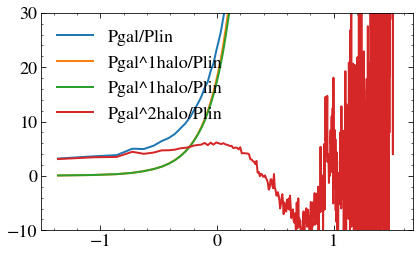

In [225]:
plt.plot(logks_tng, (Pk_gal10["power"].real)/Plin(ks_tng), label="Pgal/Plin")

#plt.plot(logks_tng, (Pk_sum10.attrs["shotnoise"])/Plin(ks_tng), label="Pgal^1halo/Plin")
plt.plot(logks_tng, (one_halo_incl_shot)/Plin(ks_tng), label="Pgal^1halo/Plin")
plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"])/Plin(ks_tng), label="Pgal^2halo/Plin")
#plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]+one_halo_incl_shot)/Plin(ks_tng), label="Pgal^1halo/Plin")

plt.legend()
plt.ylim(-10,30)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in log10
  after removing the cwd from sys.path.


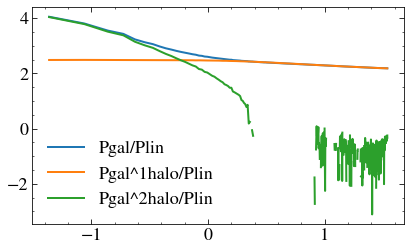

In [217]:
plt.plot(logks_tng, np.log10(Pk_gal10["power"].real), label="Pgal/Plin")

plt.plot(logks_tng, np.log10(one_halo_incl_shot), label="Pgal^1halo/Plin")
plt.plot(logks_tng, np.log10(Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]), label="Pgal^2halo/Plin")
#plt.plot(logks_tng, (Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]+one_halo_incl_shot)/Plin(ks_tng), label="Pgal^1halo/Plin")

plt.legend()
#plt.ylim(-10,20)